In [521]:
!pip install gensim
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [522]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string 
import re 
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import train_test_split
import textwrap
import matplotlib.patches as mpatches
from gensim.models import Word2Vec
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import nltk
nltk.download('punkt_tab') 

from sklearn.ensemble import RandomForestClassifier
import pickle
from sklearn.preprocessing import MinMaxScaler
from numpy import *
from IPython.display import display, HTML

[nltk_data] Downloading package wordnet to /Users/kegupta/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kegupta/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [523]:
# Loading product review dataset from Google Drive
# Using latin-1 encoding to handle special characters that might cause issues with default utf-8
reviews = pd.read_csv('https://drive.google.com/uc?export=download&id=1scp8OUht3ikqshXchS8Juyn_Yz2hUagx', encoding='latin-1')

In [524]:
reviews.head()

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part of a promotion.,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did notice, however, was the messy consistency that was reminiscent of a more liquid-y vaseline. It was difficult to clean up, and was not a pleasant, especially since it lacked the 'captivating' sensation we had both been expecting. I'm disappointed that I paid as much as I did for a lube that I won't use again, when I could just use their normal personal lubricant for 1) less money and 2) less mess.",Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,Irritation,NaN,NaN,walker557,Negative


In [525]:
reviews.isnull().sum()

id                          0
brand                       0
categories                  0
manufacturer              141
name                        0
reviews_date               46
reviews_didPurchase     14068
reviews_doRecommend      2570
reviews_rating              0
reviews_text                0
reviews_title             190
reviews_userCity        28071
reviews_userProvince    29830
reviews_username           63
user_sentiment              1
dtype: int64

In [526]:
reviews.shape

(30000, 15)

# Data Cleaning

In [527]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  object
 1   brand                 30000 non-null  object
 2   categories            30000 non-null  object
 3   manufacturer          29859 non-null  object
 4   name                  30000 non-null  object
 5   reviews_date          29954 non-null  object
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  object
 10  reviews_title         29810 non-null  object
 11  reviews_userCity      1929 non-null   object
 12  reviews_userProvince  170 non-null    object
 13  reviews_username      29937 non-null  object
 14  user_sentiment        29999 non-null  object
dtypes: int64(1), object(14)
memory usage

In [528]:
# Removing location-based columns and purchase verification as they don't contribute to sentiment analysis
# These features are not relevant for our recommendation system
reviews.drop(columns=['reviews_didPurchase', 'reviews_userCity', 'reviews_userProvince'], inplace=True)

In [529]:
# Calculating percentage of missing values to decide on column removal strategy
# Helps identify columns with high missing data that might need special handling
reviews.isnull().sum() * 100/reviews.shape[0]

id                     0.000000
brand                  0.000000
categories             0.000000
manufacturer           0.470000
name                   0.000000
reviews_date           0.153333
reviews_doRecommend    8.566667
reviews_rating         0.000000
reviews_text           0.000000
reviews_title          0.633333
reviews_username       0.210000
user_sentiment         0.003333
dtype: float64

In [530]:
reviews.head()

,id,brand,categories,manufacturer,name,reviews_date,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Just Awesome,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,NaN,5,Good flavor. This review was collected as part of a promotion.,Good,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,NaN,5,Good flavor.,Good,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,1,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did notice, however, was the messy consistency that was reminiscent of a more liquid-y vaseline. It was difficult to clean up, and was not a pleasant, especially since it lacked the 'captivating' sensation we had both been expecting. I'm disappointed that I paid as much as I did for a lube that I won't use again, when I could just use their normal personal lubricant for 1) less money and 2) less mess.",Disappointed,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,1,My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,Irritation,walker557,Negative


In [531]:
# review_date is not needed for sentiment analysis
# manufacturer is not needed as brand is already present
# reviews_doRecommend is not needed as we'll derive sentiment from text analysis instead & user_sentiment
reviews.drop(columns=['reviews_date', 'manufacturer', 'reviews_doRecommend'], inplace=True)

In [532]:
# Filling missing titles with empty strings to avoid errors when concatenating with review text
# Empty titles won't affect the sentiment analysis since we're combining title and text
reviews['reviews_title'] = reviews['reviews_title'].fillna('')

In [533]:
# Converting sentiment labels to binary classification (1=Positive, 0=Negative/Neutral)
# Treating neutral as negative since we want to identify products with positive sentiment
# This binary approach simplifies the classification task
reviews['user_sentiment'] = reviews['user_sentiment'].fillna('neutral')
reviews['user_sentiment'] = reviews['user_sentiment'].map({'Positive': 1, 'Negative': 0, 'neutral': 0})

In [534]:
# Fix data type for reviews_text
reviews['reviews_text'] = reviews['reviews_text'].astype(str)

# Exploratory data analysis

#### Univariate Analysis - Unordered categorical

In [535]:
unordered_categorical = ['brand']

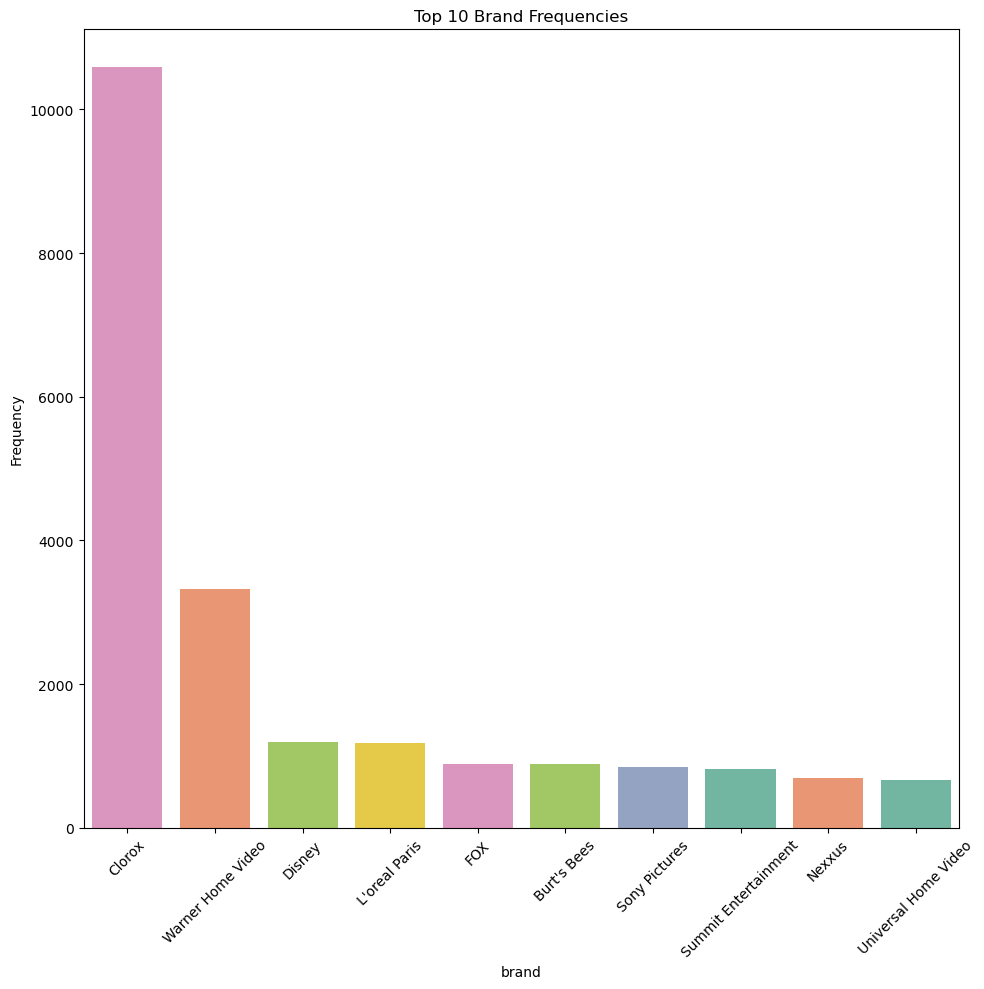

In [536]:
fig, axs = plt.subplots( len(unordered_categorical), 1, figsize=(10, 10))

# If there's only one subplot, axs is a single Axes object, not an array.
# Convert it to a list containing the single Axes object to allow iteration with index.
if len(unordered_categorical) == 1:
    axs = [axs]

# Loop through the columns and plot on each subplot
for index, col in enumerate(unordered_categorical):
    # Get top 10 most frequent categories to improve readability
    top_categories = reviews[col].value_counts().nlargest(10).index
    sns.countplot(data=reviews, x=col, hue=col, palette="Set2", ax=axs[index], order=top_categories, legend=False) # Keep legend=False for these plots
    axs[index].set_title(f'Top 10 {col.capitalize()} Frequencies') # Update title for clarity
    axs[index].set_ylabel('Frequency')

    # Wrap x-axis labels directly by modifying their text property
    for label in axs[index].get_xticklabels():
        original_text = label.get_text()
        wrapped_text = textwrap.fill(original_text, width=10) # Adjust width as needed
        label.set_text(wrapped_text)
        label.set_rotation(45) # Revert to 45 degree rotation for these
        label.set_horizontalalignment('center') # Adjust alignment for wrapped labels

# Adjust the layout to avoid overlap of subplots
plt.tight_layout()

plt.show()

/var/folders/pj/9s0zzzvs4qq9hrvk_txqr9qh0000gq/T/ipykernel_4694/3269312286.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(truncated_labels, rotation=90, ha='center')


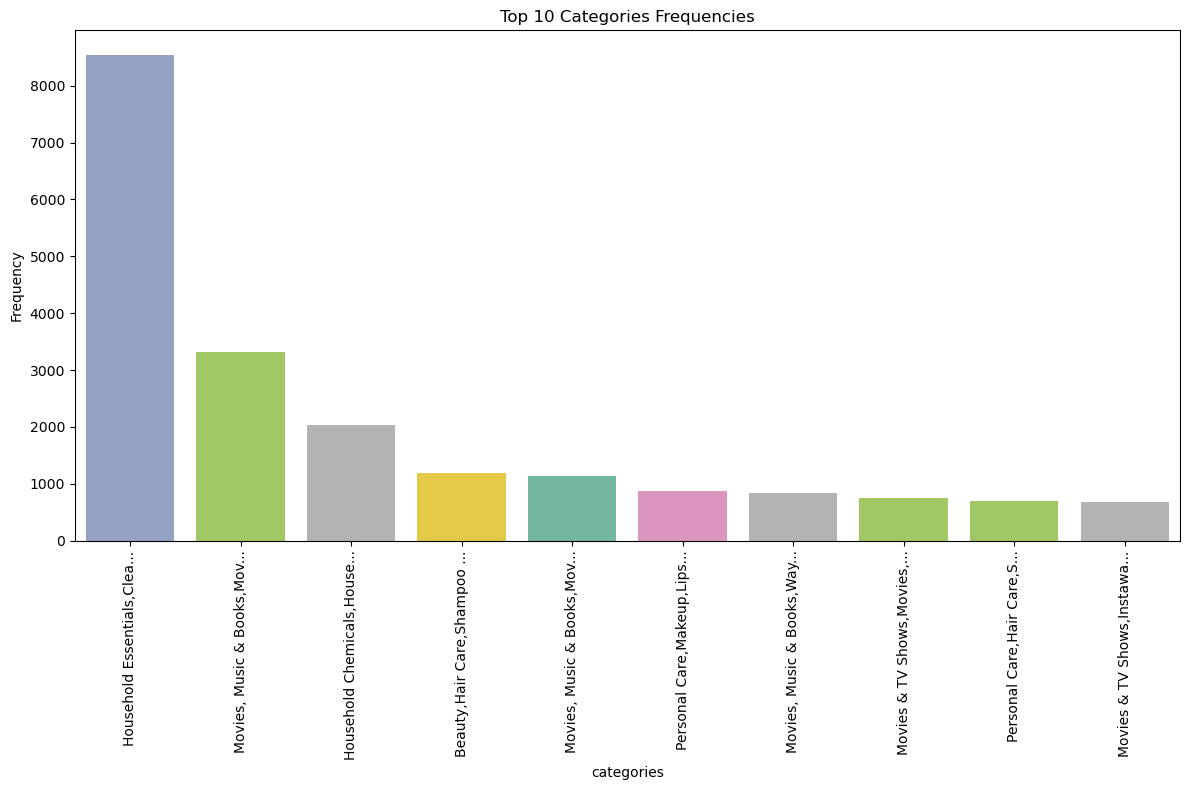

In [537]:
# Plot for 'categories' in a separate cell
plt.figure(figsize=(12, 8)) # Increased width to accommodate legend
top_categories = reviews['categories'].value_counts().nlargest(10).index
ax = sns.countplot(data=reviews, x='categories', hue='categories', palette="Set2", order=top_categories)
plt.title('Top 10 Categories Frequencies')
plt.ylabel('Frequency')

# Prepare truncated x-axis labels using the original texts
original_labels = [label.get_text() for label in ax.get_xticklabels()]
truncated_labels = []
for text in original_labels:
    if len(text) > 20:
        truncated_labels.append(text[:25] + '...')
    else:
        truncated_labels.append(text)

# Set all labels at once with rotation and alignment
ax.set_xticklabels(truncated_labels, rotation=90, ha='center')

# Adjust the layout to avoid overlap of subplots
plt.tight_layout()

plt.show()

#### Univariate Analysis - Ordered categorical

In [538]:
ordered_categorical = ['reviews_rating', 'user_sentiment']

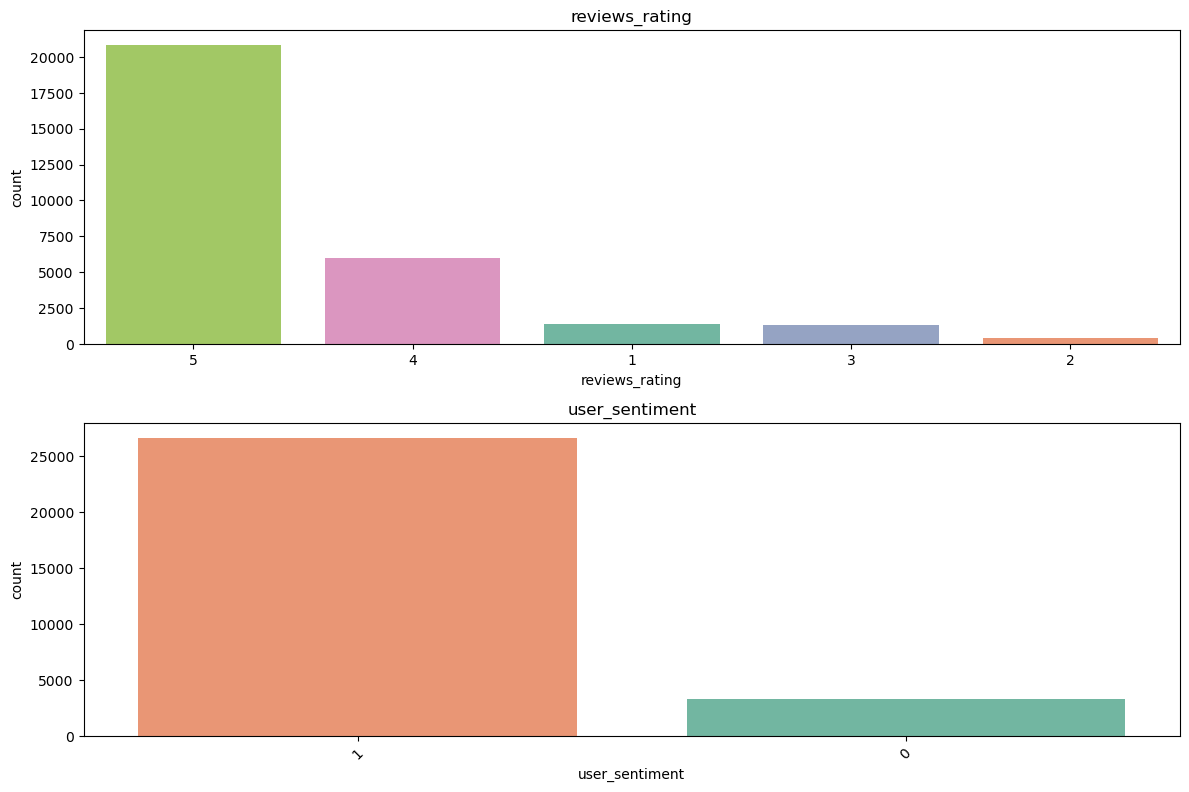

In [539]:
# Create subplots for each categorical column
fig, axs = plt.subplots( len(ordered_categorical), 1, figsize=(12, 8))

# Loop through the columns and plot on each subplot
for index, col in enumerate(ordered_categorical):
    sns.countplot(data=reviews, x=col, hue=col, palette="Set2", ax=axs[index], order=reviews[col].value_counts().index, legend=False)
    axs[index].set_title(col)  # Set title for each subplot

# Adjust the layout to avoid overlap of subplots
plt.tight_layout()
plt.xticks(rotation=45)

plt.show()

#### Bivariate Analysis

In [540]:
def count_plot_util(data, col, palette, percent, title, hue=None, y=None) :
    fig, ax = plt.subplots(figsize=(12,6), dpi=100)


    sns.countplot(data=data, x=col, palette=palette, order=reviews[col].value_counts().nlargest(20).index, hue=hue)

    plt.legend()
    plt.xticks(rotation=45)
    plt.title(title)

    plt.show()

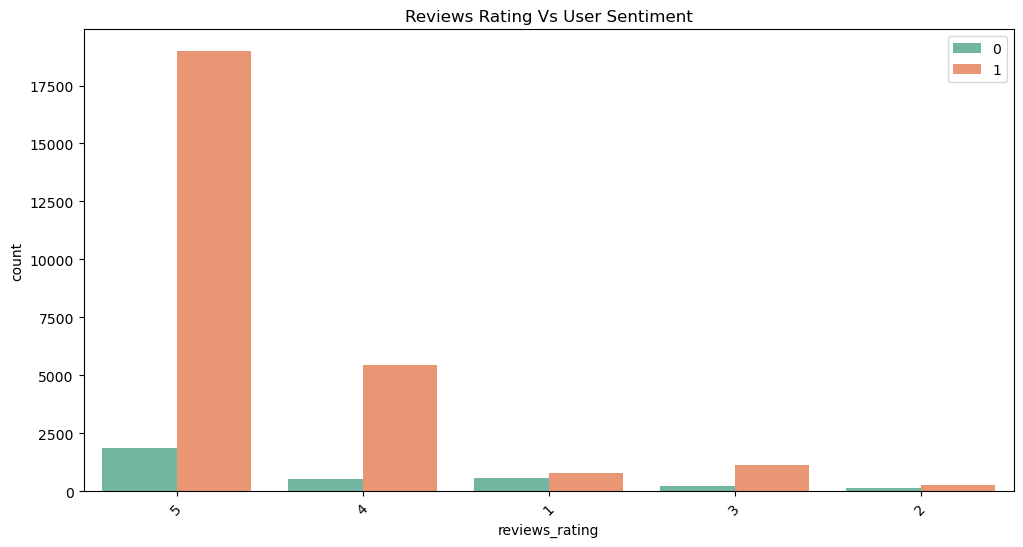

In [541]:
count_plot_util(reviews, 'reviews_rating', "Set2", False, "Reviews Rating Vs User Sentiment", 'user_sentiment')

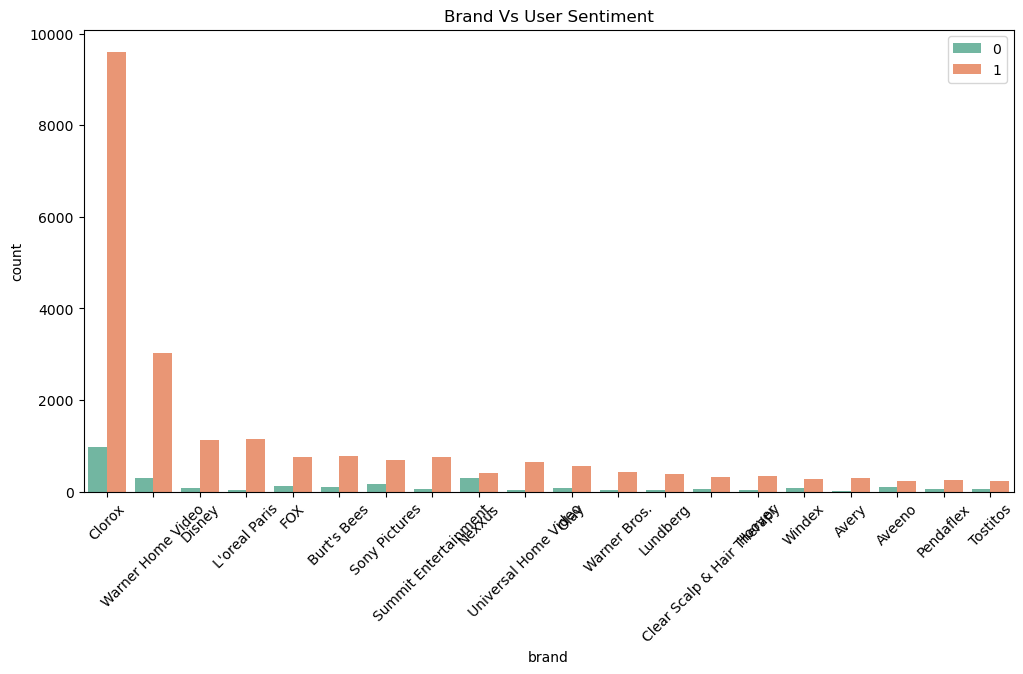

In [542]:
count_plot_util(reviews, 'brand', "Set2", True, "Brand Vs User Sentiment", 'user_sentiment')

#### Class Distribution

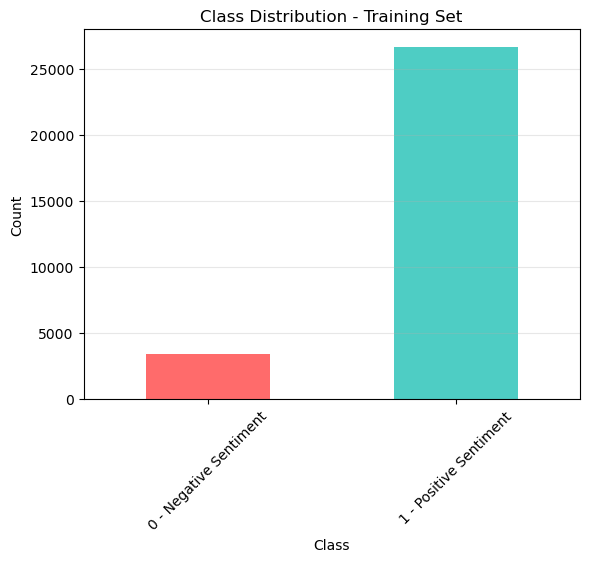

In [543]:
reviews['user_sentiment'].value_counts().sort_index().plot(kind='bar', color=['#ff6b6b', '#4ecdc4'])
plt.title('Class Distribution - Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['0 - Negative Sentiment', '1 - Positive Sentiment'], rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Text Preprocessing

#### Text Cleaning

In [544]:
# Text cleaning function to standardize review text before feature extraction
# Normalization helps reduce vocabulary size and improves model performance
def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [545]:
# Combining title and review text to capture full context
# Titles often contain key sentiment indicators that complement the main review
reviews["reviews_text"] = reviews["reviews_text"] + " " + reviews["reviews_title"]

In [546]:
# Creating cleaned text column and preparing final dataset for model training
# Selecting only essential columns: cleaned text, ratings, product ID, and sentiment labels
reviews["reviews_text_clean"] = reviews["reviews_text"].apply(clean_text)
df_final = reviews[["reviews_text_clean", "reviews_rating", "id", "user_sentiment"]]

In [547]:
reviews.head(1)

,id,brand,categories,name,reviews_rating,reviews_text,reviews_title,reviews_username,user_sentiment,reviews_text_clean
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Pink Friday: Roman Reloaded Re-Up (w/dvd),5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy. Just Awesome,Just Awesome,joshua,1,i love this album its very good more to the hip hop side than her current pop sound so hype i listen to this everyday at the gym i give it star rating all the way her metaphors are just crazy just awesome


#### Tokenization

In [548]:
df_final['reviews_text_processed'] = df_final["reviews_text_clean"].apply(nltk.word_tokenize)
display(df_final.head())

/var/folders/pj/9s0zzzvs4qq9hrvk_txqr9qh0000gq/T/ipykernel_4694/1361623657.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['reviews_text_processed'] = df_final["reviews_text_clean"].apply(nltk.word_tokenize)


,reviews_text_clean,reviews_rating,id,user_sentiment,reviews_text_processed
0,i love this album its very good more to the hip hop side than her current pop sound so hype i listen to this everyday at the gym i give it star rating all the way her metaphors are just crazy just awesome,5,AV13O1A8GV-KLJ3akUyj,1,"[i, love, this, album, its, very, good, more, to, the, hip, hop, side, than, her, current, pop, sound, so, hype, i, listen, to, this, everyday, at, the, gym, i, give, it, star, rating, all, the, way, her, metaphors, are, just, crazy, just, awesome]"
1,good flavor this review was collected as part of a promotion good,5,AV14LG0R-jtxr-f38QfS,1,"[good, flavor, this, review, was, collected, as, part, of, a, promotion, good]"
2,good flavor good,5,AV14LG0R-jtxr-f38QfS,1,"[good, flavor, good]"
3,i read through the reviews on here before looking in to buying one of the couples lubricants and was ultimately disappointed that it didnt even live up to the reviews i had read for starters neither my boyfriend nor i could notice any sort of enhanced or captivating sensation what we did notice however was the messy consistency that was reminiscent of a more liquidy vaseline it was difficult to clean up and was not a pleasant especially since it lacked the captivating sensation we had both been expecting im disappointed that i paid as much as i did for a lube that i wont use again when i could just use their normal personal lubricant for less money and less mess disappointed,1,AV16khLE-jtxr-f38VFn,0,"[i, read, through, the, reviews, on, here, before, looking, in, to, buying, one, of, the, couples, lubricants, and, was, ultimately, disappointed, that, it, didnt, even, live, up, to, the, reviews, i, had, read, for, starters, neither, my, boyfriend, nor, i, could, notice, any, sort, of, enhanced, or, captivating, sensation, what, we, did, notice, however, was, the, messy, consistency, that, was, reminiscent, of, a, more, liquidy, vaseline, it, was, difficult, to, clean, up, and, was, not, a, pleasant, especially, since, it, lacked, the, captivating, sensation, we, had, both, been, expecting, im, disappointed, that, i, paid, as, much, as, i, did, for, ...]"
4,my husband bought this gel for us the gel caused irritation and it felt like it was burning my skin i wouldnt recommend this gel irritation,1,AV16khLE-jtxr-f38VFn,0,"[my, husband, bought, this, gel, for, us, the, gel, caused, irritation, and, it, felt, like, it, was, burning, my, skin, i, wouldnt, recommend, this, gel, irritation]"


#### Removing Stopwords

In [549]:
# Removing stopwords to focus on meaningful words that carry sentiment
# Stopwords like 'the', 'is', 'at' don't contribute to sentiment classification
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df_final['reviews_text_processed'] = df_final['reviews_text_processed'].apply(remove_stopwords)
display(df_final.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kegupta/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/pj/9s0zzzvs4qq9hrvk_txqr9qh0000gq/T/ipykernel_4694/4101004505.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['reviews_text_processed'] = df_final['reviews_text_processed'].apply(remove_stopwords)


,reviews_text_clean,reviews_rating,id,user_sentiment,reviews_text_processed
0,i love this album its very good more to the hip hop side than her current pop sound so hype i listen to this everyday at the gym i give it star rating all the way her metaphors are just crazy just awesome,5,AV13O1A8GV-KLJ3akUyj,1,"[love, album, good, hip, hop, side, current, pop, sound, hype, listen, everyday, gym, give, star, rating, way, metaphors, crazy, awesome]"
1,good flavor this review was collected as part of a promotion good,5,AV14LG0R-jtxr-f38QfS,1,"[good, flavor, review, collected, part, promotion, good]"
2,good flavor good,5,AV14LG0R-jtxr-f38QfS,1,"[good, flavor, good]"
3,i read through the reviews on here before looking in to buying one of the couples lubricants and was ultimately disappointed that it didnt even live up to the reviews i had read for starters neither my boyfriend nor i could notice any sort of enhanced or captivating sensation what we did notice however was the messy consistency that was reminiscent of a more liquidy vaseline it was difficult to clean up and was not a pleasant especially since it lacked the captivating sensation we had both been expecting im disappointed that i paid as much as i did for a lube that i wont use again when i could just use their normal personal lubricant for less money and less mess disappointed,1,AV16khLE-jtxr-f38VFn,0,"[read, reviews, looking, buying, one, couples, lubricants, ultimately, disappointed, didnt, even, live, reviews, read, starters, neither, boyfriend, could, notice, sort, enhanced, captivating, sensation, notice, however, messy, consistency, reminiscent, liquidy, vaseline, difficult, clean, pleasant, especially, since, lacked, captivating, sensation, expecting, im, disappointed, paid, much, lube, wont, use, could, use, normal, personal, lubricant, less, money, less, mess, disappointed]"
4,my husband bought this gel for us the gel caused irritation and it felt like it was burning my skin i wouldnt recommend this gel irritation,1,AV16khLE-jtxr-f38VFn,0,"[husband, bought, gel, us, gel, caused, irritation, felt, like, burning, skin, wouldnt, recommend, gel, irritation]"


#### Lemmatization

In [550]:
# Lemmatization reduces words to their root form (e.g., 'running' -> 'run')
# This helps Word2Vec learn better word representations by grouping related word forms
lemmatizer = WordNetLemmatizer()

def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df_final['reviews_text_processed'] = df_final['reviews_text_processed'].apply(lemmatize_words)
display(df_final.head())

/var/folders/pj/9s0zzzvs4qq9hrvk_txqr9qh0000gq/T/ipykernel_4694/2683862855.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['reviews_text_processed'] = df_final['reviews_text_processed'].apply(lemmatize_words)


,reviews_text_clean,reviews_rating,id,user_sentiment,reviews_text_processed
0,i love this album its very good more to the hip hop side than her current pop sound so hype i listen to this everyday at the gym i give it star rating all the way her metaphors are just crazy just awesome,5,AV13O1A8GV-KLJ3akUyj,1,"[love, album, good, hip, hop, side, current, pop, sound, hype, listen, everyday, gym, give, star, rating, way, metaphor, crazy, awesome]"
1,good flavor this review was collected as part of a promotion good,5,AV14LG0R-jtxr-f38QfS,1,"[good, flavor, review, collected, part, promotion, good]"
2,good flavor good,5,AV14LG0R-jtxr-f38QfS,1,"[good, flavor, good]"
3,i read through the reviews on here before looking in to buying one of the couples lubricants and was ultimately disappointed that it didnt even live up to the reviews i had read for starters neither my boyfriend nor i could notice any sort of enhanced or captivating sensation what we did notice however was the messy consistency that was reminiscent of a more liquidy vaseline it was difficult to clean up and was not a pleasant especially since it lacked the captivating sensation we had both been expecting im disappointed that i paid as much as i did for a lube that i wont use again when i could just use their normal personal lubricant for less money and less mess disappointed,1,AV16khLE-jtxr-f38VFn,0,"[read, review, looking, buying, one, couple, lubricant, ultimately, disappointed, didnt, even, live, review, read, starter, neither, boyfriend, could, notice, sort, enhanced, captivating, sensation, notice, however, messy, consistency, reminiscent, liquidy, vaseline, difficult, clean, pleasant, especially, since, lacked, captivating, sensation, expecting, im, disappointed, paid, much, lube, wont, use, could, use, normal, personal, lubricant, less, money, less, mess, disappointed]"
4,my husband bought this gel for us the gel caused irritation and it felt like it was burning my skin i wouldnt recommend this gel irritation,1,AV16khLE-jtxr-f38VFn,0,"[husband, bought, gel, u, gel, caused, irritation, felt, like, burning, skin, wouldnt, recommend, gel, irritation]"


In [551]:
df_final.drop(columns=['reviews_text_clean'])

,reviews_rating,id,user_sentiment,reviews_text_processed
0,5,AV13O1A8GV-KLJ3akUyj,1,"[love, album, good, hip, hop, side, current, pop, sound, hype, listen, everyday, gym, give, star, rating, way, metaphor, crazy, awesome]"
1,5,AV14LG0R-jtxr-f38QfS,1,"[good, flavor, review, collected, part, promotion, good]"
2,5,AV14LG0R-jtxr-f38QfS,1,"[good, flavor, good]"
3,1,AV16khLE-jtxr-f38VFn,0,"[read, review, looking, buying, one, couple, lubricant, ultimately, disappointed, didnt, even, live, review, read, starter, neither, boyfriend, could, notice, sort, enhanced, captivating, sensation, notice, however, messy, consistency, reminiscent, liquidy, vaseline, difficult, clean, pleasant, especially, since, lacked, captivating, sensation, expecting, im, disappointed, paid, much, lube, wont, use, could, use, normal, personal, lubricant, less, money, less, mess, disappointed]"
4,1,AV16khLE-jtxr-f38VFn,0,"[husband, bought, gel, u, gel, caused, irritation, felt, like, burning, skin, wouldnt, recommend, gel, irritation]"
...,...,...,...,...
29995,5,AVpfW8y_LJeJML437ySW,1,"[got, conditioner, influenster, try, im, loving, far, oily, hair, use, end, hair, feel, amazing, soft, mess, review, collected, part, promotion, softness]"
29996,5,AVpfW8y_LJeJML437ySW,1,"[love, received, review, purpose, influenster, leaf, hair, feeling, fresh, smelling, great, love]"
29997,5,AVpfW8y_LJeJML437ySW,1,"[first, love, smell, product, wash, hair, smooth, easy, brush, receive, product, influenster, testing, purpose, opinion, review, collected, part, promotion, hair, smooth, use]"
29998,5,AVpfW8y_LJeJML437ySW,1,"[received, influenster, never, go, back, anything, else, normally, dont, use, conditioner, hair, oily, fine, make, hair, feel, heavy, doesnt, get, oily, day, really, fantastic, plan, buying, future, review, collected, part, promotion, perfect, oily, hair]"


# Feature Extraction


In [552]:
# Training Word2Vec to create dense vector representations of words
# CBOW (sg=0) is faster and works well with smaller datasets
# These embeddings capture semantic relationships between words in product reviews
word2vec_model = Word2Vec(sentences=df_final['reviews_text_processed'],
                          min_count=1,
                          vector_size=100,
                          window=5,
                          workers=4,
                          sg=0)

In [553]:
# Converting each review into a fixed-size vector by averaging word embeddings
# This creates a single 100-dimensional feature vector per review for classification
# Handles out-of-vocabulary words gracefully by returning zero vector if no words match
def document_vector(word2vec_model, doc):
    # remove out-of-vocabulary words
    doc = [word for word in doc if word in word2vec_model.wv.index_to_key]
    if len(doc) == 0:
        return np.zeros(word2vec_model.wv.vector_size)
    return np.mean(word2vec_model.wv[doc], axis=0)

# Apply the function to create feature vectors for each review
df_final['review_vectors'] = df_final['reviews_text_processed'].apply(lambda x: document_vector(word2vec_model, x))

/var/folders/pj/9s0zzzvs4qq9hrvk_txqr9qh0000gq/T/ipykernel_4694/107225051.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['review_vectors'] = df_final['reviews_text_processed'].apply(lambda x: document_vector(word2vec_model, x))


In [554]:
display(df_final.head())

,reviews_text_clean,reviews_rating,id,user_sentiment,reviews_text_processed,review_vectors
0,i love this album its very good more to the hip hop side than her current pop sound so hype i listen to this everyday at the gym i give it star rating all the way her metaphors are just crazy just awesome,5,AV13O1A8GV-KLJ3akUyj,1,"[love, album, good, hip, hop, side, current, pop, sound, hype, listen, everyday, gym, give, star, rating, way, metaphor, crazy, awesome]","[-0.00850085, 0.088248864, 0.14785485, 0.12122315, -0.09937211, -0.39415842, 0.049226947, 0.5546313, -0.46398002, -0.34921414, -0.099019274, -0.39306143, 0.26444107, 0.04779795, 0.091577075, -0.13137178, -0.032343872, 0.11387018, -0.005359465, -0.39755085, 0.12990409, 0.20744178, 0.09518911, -0.031532414, 0.062292524, 0.11287409, -0.22440378, -0.35397604, -0.14785552, -0.032737985, -0.2669886, 0.09617426, 0.00013332962, -0.30018297, -0.41723552, 0.4383648, -0.35695004, -0.28310657, -0.2913146, -0.490678, -0.19644676, -0.18034151, -0.22149174, 0.06574555, -0.049161553, -0.0635741, 0.061627723, -0.35527092, -0.28769717, 0.2629318, 0.016503345, -0.61775553, 0.3571809, -0.17392538, -0.33230326, -0.091246285, -0.03512466, -0.06520294, -0.32757527, -0.023333168, 0.3484059, -0.17383692, -0.41046602, -0.43429312, -0.3480576, 0.3893516, -0.20871167, 0.33874646, -0.25448853, -0.0037426024, -0.31680807, 0.027861154, 0.25313565, -0.39207274, 0.07784758, 0.17563564, -0.33230716, 0.24843161, -0.29051653, 0.08250864, -0.074726425, 0.114514686, -0.1640698, 0.13418415, -0.2900173, 0.08900419, 0.0927436, 0.17720567, 0.12713112, -0.26766902, 0.4516604, -0.3860367, 0.094527215, 0.0636755, 0.16444926, 0.09252921, 0.2730619, -0.32335955, 0.14086819, -0.22413059]"
1,good flavor this review was collected as part of a promotion good,5,AV14LG0R-jtxr-f38QfS,1,"[good, flavor, review, collected, part, promotion, good]","[0.1894867, 0.35980287, 0.483331, 0.38169673, -0.44713706, -0.5165276, 0.05251605, 0.12770486, -0.6020977, -0.74948436, 0.15767649, 0.23481777, 0.30526394, -0.12561932, 0.47234344, -0.24052075, 0.0010328932, 0.18257894, 0.60840166, -0.8159341, -0.06935329, 0.55967003, 0.25076714, 0.16002811, 0.34650877, -0.03240599, -0.83149004, -0.33498654, 0.10332354, 0.12379641, -0.7836132, -0.14097692, -0.03124935, -1.2030922, -1.0263784, 1.0089859, -1.5198125, -0.45164797, -0.0038448323, -1.4330559, -0.33488718, -0.41409534, 0.026280072, 0.8172893, -0.13080586, -0.3869268, -0.15549882, -0.45584297, -0.6714366, 0.37152913, 0.21749237, -1.2369782, 0.8354029, -0.2934785, -1.0644839, -0.18662834, -0.19913475, -0.8493337, -0.6599559, -0.39647922, 0.38527307, -0.28698388, -0.91422814, -0.4519589, -0.33226997, 1.3453251, -0.5540713, 1.0732981, -0.08331327, -0.23083052, -0.69981486, 0.31282473, 0.7907953, -0.5911436, 0.04516963, 0.3932281, -0.52610177, 0.17135596, -0.406445, -0.1419846, 0.14567278, -0.244332, -0.52147925, -0.23291741, -0.14552207, -0.0885176, 0.9081717, 0.008060501, -0.18588711, -0.34498253, 0.8286212, -0.77377045, -0.46388936, -0.12771131, -0.384361, -0.29237255, 0.83774036, -0.5063653, 0.44678053, -0.9888191]"
2,good flavor good,5,AV14LG0R-jtxr-f38QfS,1,"[good, flavor, good]","[0.23180275, 0.6964979, 0.54052895, 0.17130196, -0.2005889, -1.113989, 0.38857841, 1.5762128, -0.9023879, -1.2061776, 0.2936248, -0.47244287, 0.42641428, 0.06173796, 0.09339517, -0.32372877, 0.2092973, 0.43205753, 0.27199122, -0.66031, 0.40656188, 0.22834276, 0.70902205, 0.08451017, -0.25528136, 0.3654492, -0.1675579, 0.35160255, -0.15667808, 0.69991285, -0.06233786, -0.12678774, -0.1542158, -0.38521007, -0.5120837, 0.8988305, -0.5446057, -0.17867638, -0.09317095, -0.93332714, -0.1152133, 0.15211804, -0.5417318, 0.38811526, -0.009419481, -0.2297679, -0.03539012, -0.5688509, -0.35127163, 0.3278682, -0.017929038, -0.81808966, 0.738056, -1.085775, -0.30526337, -0.36468804, -0.5003765, -0.9673927, -0.19715486, -0.119539924, 0.38675988, -0.80069613, -0.56490606, -0.9024127, -0.4154236, 0.8519983, -0.06730125, 0.691197,

# Training text classification model

#### Train Test Split

In [555]:
# Splitting data with stratification to maintain class distribution in train/test sets
# Important for imbalanced datasets to ensure both sets have similar positive/negative ratios
X = np.array(df_final['review_vectors'].tolist())
y = df_final['user_sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (21000, 100)
Shape of X_test: (9000, 100)
Shape of y_train: (21000,)
Shape of y_test: (9000,)


#### Logistic Regression

In [556]:
# Comprehensive evaluation function that calculates multiple metrics for model comparison
# Focuses on per-class metrics since we have imbalanced data (more positive than negative reviews)
# ROC-AUC provides threshold-independent performance measure
def evaluate_model(X_test, y_test, y_pred_proba, y_pred, model_name):
    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))
    
    # Per-class metrics
    print("Per-class metrics:")
    precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    recall_0 = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
    f1_0 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall_1 = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    print(f"Precision (0): {precision_0:.4f}, Recall (0): {recall_0:.4f}, F1 (0): {f1_0:.4f}")
    print(f"Precision (1): {precision_1:.4f}, Recall (1): {recall_1:.4f}, F1 (1): {f1_1:.4f}")

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
            label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.show()
    print(f"ROC-AUC = {roc_auc:.4f}")
    # Return metrics dictionary
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'F1-Score (Class 0)': f1_0,
        'Recall (Class 0)': recall_0,
        'Precision (Class 0)': precision_0,
        'F1-Score (Class 1)': f1_1,
        'Recall (Class 1)': recall_1,
        'Precision (Class 1)': precision_1,
        'ROC-AUC': roc_auc
    }

In [557]:
# Using balanced class weights to handle imbalanced dataset (many more positive than negative reviews)
# This prevents the model from simply predicting the majority class
logistic_regression = LogisticRegression(
                            class_weight='balanced', 
                            max_iter=1000,
                            random_state=42)
logistic_regression.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Accuracy: 0.7118888888888889

Classification Report:

              precision    recall  f1-score   support

           0       0.25      0.77      0.37      1010
           1       0.96      0.70      0.81      7990

    accuracy                           0.71      9000
   macro avg       0.60      0.74      0.59      9000
weighted avg       0.88      0.71      0.76      9000


Confusion Matrix:

[[ 775  235]
 [2358 5632]]
Per-class metrics:
Precision (0): 0.2474, Recall (0): 0.7673, F1 (0): 0.3741
Precision (1): 0.9599, Recall (1): 0.7049, F1 (1): 0.8129


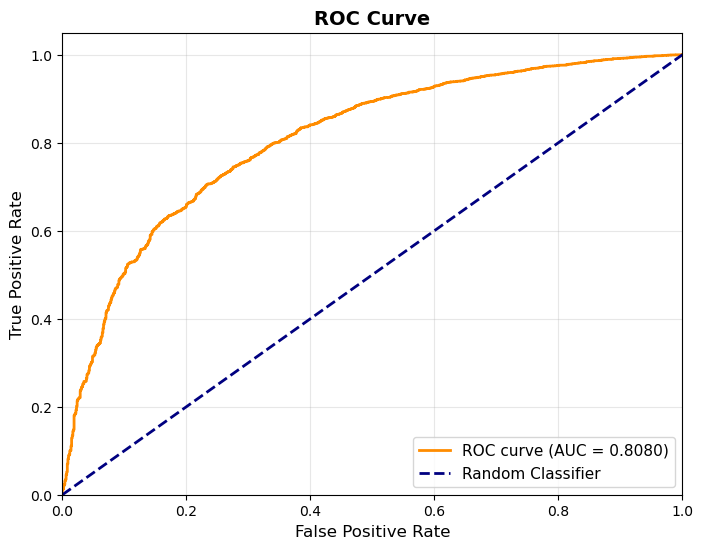

ROC-AUC = 0.8080


In [558]:
# Make predictions on the test set
y_pred_lr = logistic_regression.predict(X_test)
y_pred_proba_lr = logistic_regression.predict_proba(X_test)[:,1]
lr_metrics = evaluate_model(X_test, y_test, y_pred_proba_lr, y_pred_lr, "Logistic Regression")

#### XGBoost

In [559]:
# Grid search for XGBoost hyperparameter tuning
# scale_pos_weight addresses class imbalance by penalizing misclassification of minority class
# Testing multiple values to find optimal balance between precision and recall
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'scale_pos_weight': [7.9, 10.0, 15.0],  # For imbalanced data

}

xgboost_class = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Perform GridSearchCV with coarse grid
print("Starting GridSearchCV for XGBoost (coarse grid)...")
xgb_grid = GridSearchCV(
    estimator=xgboost_class,
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(X_train, y_train)
xgb_grid.best_params_

Starting GridSearchCV for XGBoost (coarse grid)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=15.0; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=10.0; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=15.0; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=7.9; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=10.0; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=15.0; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=7.9; total time=   0.5s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=10.0; total time=   0.5s[CV] END learning_rate=0.01, max_depth=3, n_estimators=50, scale_pos_weight=15.0;

/opt/homebrew/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, scale_pos_weight=7.9; total time=   5.4s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, scale_pos_weight=7.9; total time=   4.4s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, scale_pos_weight=10.0; total time=   4.3s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, scale_pos_weight=10.0; total time=   4.3s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, scale_pos_weight=15.0; total time=   4.1s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, scale_pos_weight=10.0; total time=   4.5s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, scale_pos_weight=7.9; total time=   5.4s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, scale_pos_weight=10.0; total time=   5.0s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, scale_pos_weight=7.9; total time=   5.5s
[CV] END learning_rate=0.01, max_depth=7, n_estimators=200, scale_pos_weight=7.9; tota

{'learning_rate': 0.2,
 'max_depth': 7,
 'n_estimators': 200,
 'scale_pos_weight': 10.0}

In [560]:

xgb_final_model_new = XGBClassifier(
    **xgb_grid.best_params_,  # Unpack best parameters
    random_state=42,
    eval_metric='logloss'
)
xgb_final_model_new.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Accuracy: 0.9064444444444445

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.23      0.36      1010
           1       0.91      0.99      0.95      7990

    accuracy                           0.91      9000
   macro avg       0.84      0.61      0.65      9000
weighted avg       0.90      0.91      0.88      9000


Confusion Matrix:

[[ 237  773]
 [  69 7921]]
Per-class metrics:
Precision (0): 0.7745, Recall (0): 0.2347, F1 (0): 0.3602
Precision (1): 0.9111, Recall (1): 0.9914, F1 (1): 0.9495


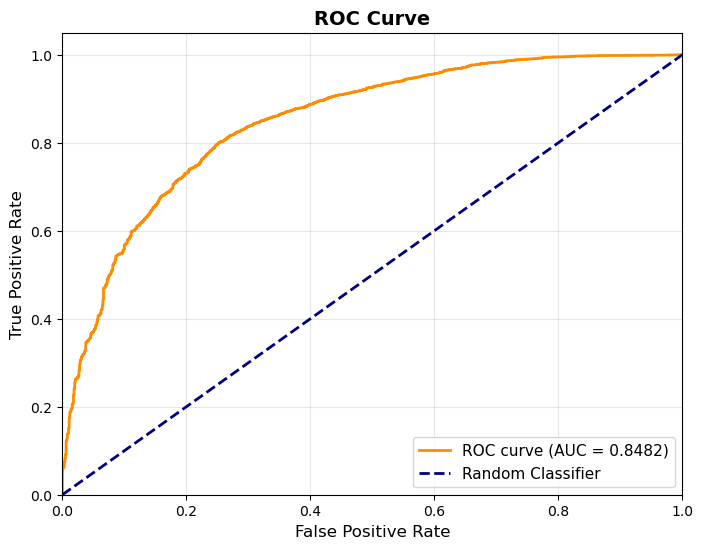

ROC-AUC = 0.8482


In [561]:
y_pred_xgb = xgb_final_model_new.predict(X_test)
y_pred_proba_xgb = xgb_final_model_new.predict_proba(X_test)[:,1]
xgb_metrics = evaluate_model(X_test, y_test, y_pred_proba_xgb, y_pred_xgb, "XGBoost" )

#### Random forest

In [562]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [
        'balanced',
        {0: 7.9, 1: 1.0},
        {0: 10.0, 1: 1.0}
    ],
}
print("Hyperparameter grid defined:")
print(param_grid)

Hyperparameter grid defined:
{'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'class_weight': ['balanced', {0: 7.9, 1: 1.0}, {0: 10.0, 1: 1.0}]}


In [563]:
# Initialize RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Grid search completed. Best parameters will be identified in the next step.")

Fitting 3 folds for each of 243 candidates, totalling 729 fits
[CV] END class_weight=balanced, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   4.9s
[CV] END class_weight=balanced, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   5.0s
[CV] END class_weight=balanced, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   5.1s
[CV] END class_weight=balanced, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   5.1s
[CV] END class_weight=balanced, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   5.1s
[CV] END class_weight=balanced, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   5.2s
[CV] END class_weight=balanced, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   9.9s
[CV] END class_weight=balanced, max_depth=None, min_samples_l

In [564]:
grid_search.best_params_

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 200}

In [565]:
# Using best parameters from grid search, but note: grid search included class_weight options
# Final model uses default class_weight, which may explain performance differences
rf_classifier = RandomForestClassifier(random_state=42, n_estimators=200, min_samples_split=2)
rf_classifier.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

Accuracy: 0.9051111111111111

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.20      0.32      1010
           1       0.91      0.99      0.95      7990

    accuracy                           0.91      9000
   macro avg       0.86      0.60      0.63      9000
weighted avg       0.90      0.91      0.88      9000


Confusion Matrix:

[[ 201  809]
 [  45 7945]]
Per-class metrics:
Precision (0): 0.8171, Recall (0): 0.1990, F1 (0): 0.3201
Precision (1): 0.9076, Recall (1): 0.9944, F1 (1): 0.9490


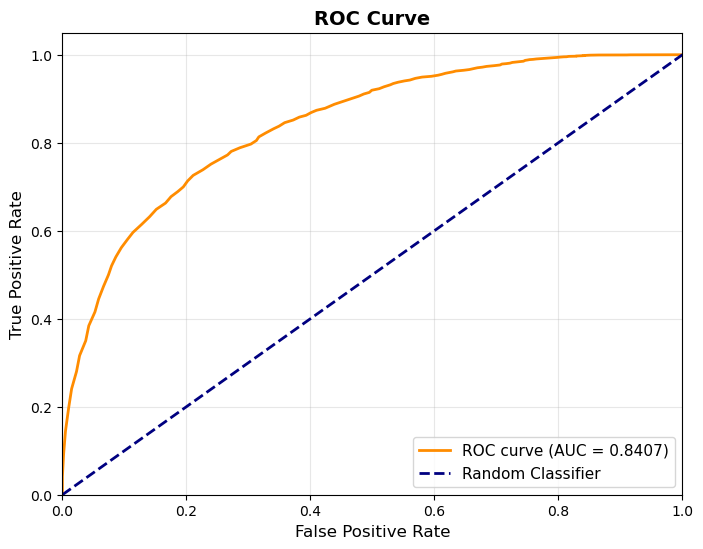

ROC-AUC = 0.8407


In [566]:
y_pred_rf = rf_classifier.predict(X_test)
y_pred_proba_rf = rf_classifier.predict_proba(X_test)[:,1]
rf_metrics = evaluate_model(X_test, y_test, y_pred_proba_rf, y_pred_rf, "Random Forest")

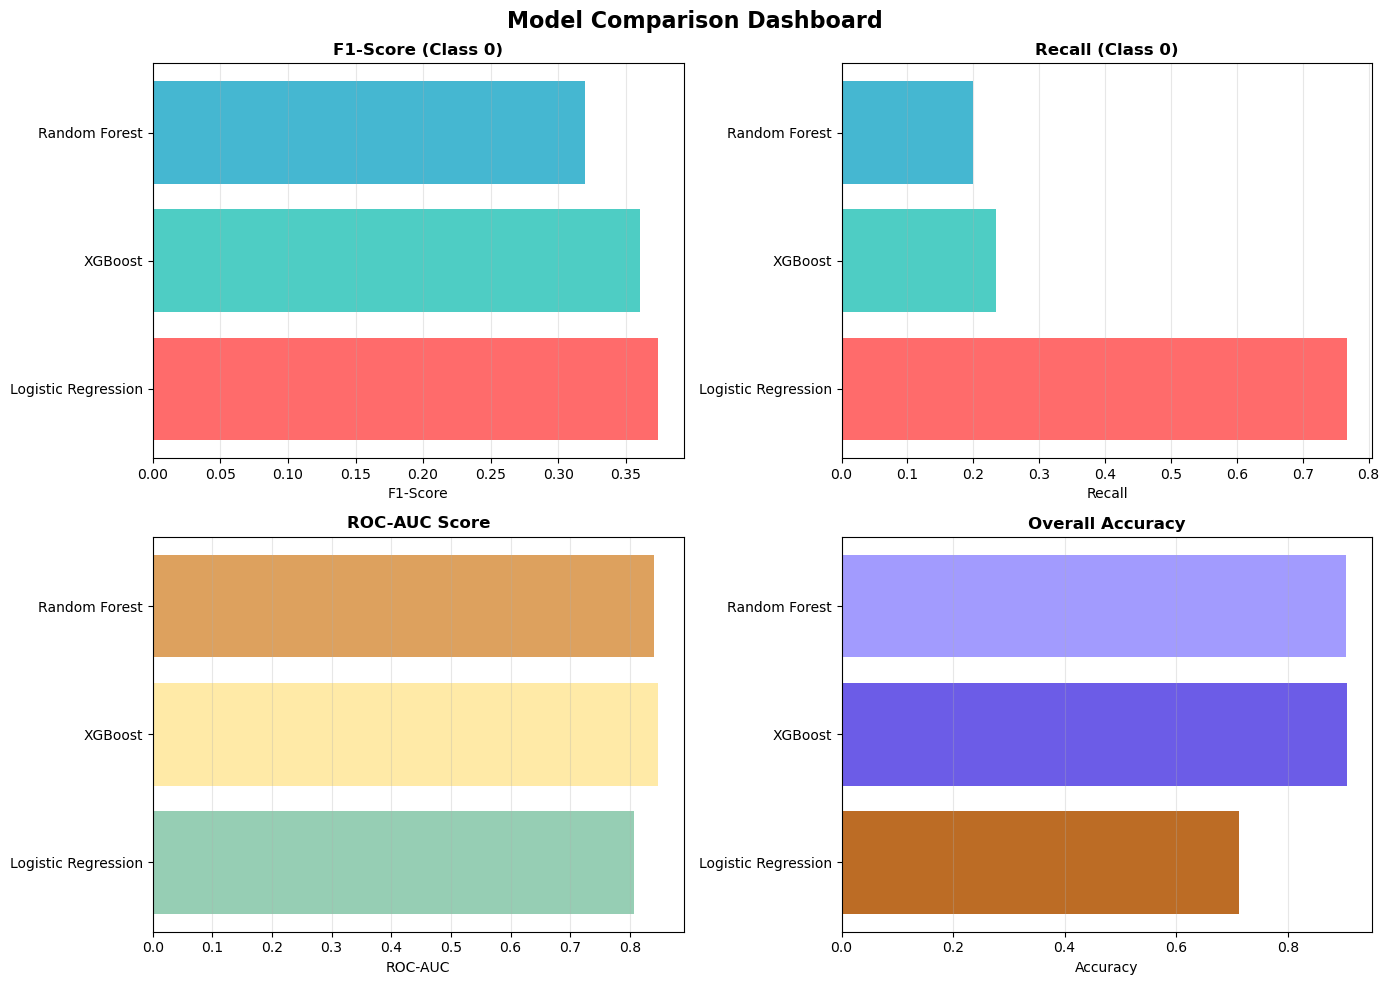

BEST MODEL: Logistic Regression
F1-Score (Class 0): 0.3741
Recall (Class 0): 0.7673


In [567]:
# Comparing all three models across multiple metrics to select the best one
# Visual dashboard helps identify trade-offs between different performance measures
df = pd.DataFrame([lr_metrics, xgb_metrics, rf_metrics])

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison Dashboard', fontsize=16, fontweight='bold')

# 1. F1-Score (Class 0)
axes[0, 0].barh(df['Model'], df['F1-Score (Class 0)'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_title('F1-Score (Class 0)', fontweight='bold')
axes[0, 0].set_xlabel('F1-Score')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Recall (Class 0)
axes[0, 1].barh(df['Model'], df['Recall (Class 0)'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 1].set_title('Recall (Class 0)', fontweight='bold')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. ROC-AUC
axes[1, 0].barh(df['Model'], df['ROC-AUC'], color=['#96CEB4', '#FFEAA7', '#DDA15E'])
axes[1, 0].set_title('ROC-AUC Score', fontweight='bold')
axes[1, 0].set_xlabel('ROC-AUC')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Accuracy
axes[1, 1].barh(df['Model'], df['Accuracy'], color=['#BC6C25', '#6C5CE7', '#A29BFE'])
axes[1, 1].set_title('Overall Accuracy', fontweight='bold')
axes[1, 1].set_xlabel('Accuracy')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("="*70)
print("BEST MODEL: Logistic Regression")
print(f"F1-Score (Class 0): {df.loc[0, 'F1-Score (Class 0)']:.4f}")
print(f"Recall (Class 0): {df.loc[0, 'Recall (Class 0)']:.4f}")


Model selection rationale: Logistic Regression chosen despite lower overall accuracy

Higher recall for negative reviews (0.76) means we catch more problematic products

This trade-off is valuable for recommendation systems where missing negative reviews is costly

In [ ]:
# Saving Logistic Regression model (despite variable name suggesting RF)
# This is the chosen model based on better recall for negative reviews
with open('Deployment/model.pkl', 'wb') as f:
    pickle.dump(logistic_regression, f)

## Recommendation System

In [569]:
# Splitting original reviews dataset for recommendation system evaluation
# Different random_state (31) ensures recommendation train/test is independent from sentiment model split
train, test = train_test_split(reviews, test_size=0.30, random_state=31)

In [570]:
# Creating a mask matrix: 1 indicates items user hasn't rated (candidates for recommendation)
# 0 indicates items already rated (will be filtered out from recommendations)
# This prevents recommending products the user has already reviewed
dummy_train = train.pivot_table(index='reviews_username', columns='id', 
                    values='reviews_rating', aggfunc='mean').fillna(1)
dummy_train.shape

(18252, 252)

## Item based Recommendation System

In [571]:
# Creating user-item rating matrix for item-based collaborative filtering
# Transposed so items are rows and users are columns for similarity calculation
df_pivot = train.pivot_table(index='reviews_username', columns='id', values='reviews_rating', aggfunc='mean').T

In [572]:
# Mean-centering ratings to account for user rating bias
# Some users rate higher on average, so we subtract item means before computing similarity
mean = np.nanmean(df_pivot, axis=1)
df_subtracted = (df_pivot.T-mean).T

In [573]:
# Computing item-item similarity using cosine similarity on mean-centered ratings
# Similarity ranges from 0 to 1, where 1 means identical rating patterns across users
item_correlation = 1 - pairwise_distances(df_subtracted.fillna(0), metric='cosine')
item_correlation[np.isnan(item_correlation)] = 0
print(item_correlation)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


In [574]:
# Removing negative correlations (dissimilar items) as they don't help in recommendations
# Only positive correlations indicate items that users rate similarly
item_correlation[item_correlation<0]=0
item_correlation

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

##### Prediction

In [575]:
# Predicting ratings by weighted sum of similar items' ratings
# Each item's rating contributes proportionally to its similarity with the target item
item_predicted_ratings = np.dot((df_pivot.fillna(0).T),item_correlation)
item_predicted_ratings

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.0124448 , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.00053645, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00134112, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00713081, 0.        ,
        0.        ]])

##### Filtering the rating only for the items not rated by the user for recommendation

In [576]:
# Filtering out items user has already rated by multiplying with dummy_train mask
# Only unrated items will have non-zero final ratings for recommendation
item_final_rating = np.multiply(item_predicted_ratings,dummy_train)
item_final_rating.head()

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfs0tUilAPnD_xgqN2,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,0.0,0.0,0.000000,0.023523,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
00sab00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000573,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
01impala,0.0,0.0,0.012445,0.000000,0.0,0.0,0.0,0.0,0.000000,0.004599,...,0.007731,0.001157,0.075997,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
0325home,0.0,0.0,0.000000,0.001556,0.0,0.0,0.0,0.0,0.001952,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.001341,0.0,0.0
06stidriver,0.0,0.0,0.000000,0.001556,0.0,0.0,0.0,0.0,0.001952,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.001341,0.0,0.0


##### Finding the top 5 recommendation for the *user*



In [577]:
# Take the user ID as input
user_input = input("Enter your user name: ").strip()

In [578]:
d = item_final_rating.loc[user_input].sort_values(ascending=False)[0:5]
d

id
AVpfPaoqLJeJML435Xk9    9.000000
AVpf5olc1cnluZ0-tPrO    0.121329
AVpfozgyilAPnD_xfe0r    0.107870
AVpfrTyiLJeJML43BrSI    0.075997
AVpfRTh1ilAPnD_xYic2    0.052110
Name: 01impala, dtype: float64

In [579]:
d = pd.merge(d, reviews, on='id', how='inner')
d.head()

,id,01impala,brand,categories,name,reviews_rating,reviews_text,reviews_title,reviews_username,user_sentiment,reviews_text_clean
0,AVpfPaoqLJeJML435Xk9,9.0,Warner Home Video,"Movies, Music & Books,Movies,Action & Adventure,Movies & Music,Movies & TV Shows,Frys",Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,1,could have left this one on the shelf but it had a great box awful,awful,primoconcept,1,could have left this one on the shelf but it had a great box awful
1,AVpfPaoqLJeJML435Xk9,9.0,Warner Home Video,"Movies, Music & Books,Movies,Action & Adventure,Movies & Music,Movies & TV Shows,Frys",Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,1,"This movie is much worse that expected. The 1997 Broderick movie is much better. The producers went back to the popular Japanese format that were great for teenagers, but just doesn't work for adults. Much worse than expected",Much worse than expected,terrym,1,this movie is much worse that expected the broderick movie is much better the producers went back to the popular japanese format that were great for teenagers but just doesnt work for adults much worse than expected
2,AVpfPaoqLJeJML435Xk9,9.0,Warner Home Video,"Movies, Music & Books,Movies,Action & Adventure,Movies & Music,Movies & TV Shows,Frys",Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,1,"Just don't get the hype about Godzilla. Frankly movie was boring, build up was slow and just not interesting or even worth it. I was even more disappointed to hear Pacific Rim 2 was put on hold for Godzilla vs King Kong if its anything like this movie I'll pass. Oh and because a movie is like the original doesn't make it good, times have changed and an update to the story would work for the new generations. Just dont get the hype",Just dont get the hype,mrme,0,just dont get the hype about godzilla frankly movie was boring build up was slow and just not interesting or even worth it i was even more disappointed to hear pacific rim was put on hold for godzilla vs king kong if its anything like this movie ill pass oh and because a movie is like the original doesnt make it good times have changed and an update to the story would work for the new generations just dont get the hype
3,AVpfPaoqLJeJML435Xk9,9.0,Warner Home Video,"Movies, Music & Books,Movies,Action & Adventure,Movies & Music,Movies & TV Shows,Frys",Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,1,A little disappointed its not like the Godzilla movies years back. Not the best item,Not the best item,3dknights,0,a little disappointed its not like the godzilla movies years back not the best item
4,AVpfPaoqLJeJML435Xk9,9.0,Warner Home Video,"Movies, Music & Books,Movies,Action & Adventure,Movies & Music,Movies & TV Shows,Frys",Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd,1,"It was on sale, so I bought it. After I got it the case was broken in half witch sucks a lot. But at least the disk are ok I guess. Will not order online if this happens. Good movie, bad packaging.","Good movie, bad packaging.",master,0,it was on sale so i bought it after i got it the case was broken in half witch sucks a lot but at least the disk are ok i guess will not order online if this happens good movie bad packaging


#### Evaluation - Item Based Recommendation

In [580]:
# Filtering test set to only include products present in training set
# This is necessary for item-based CF since we can only compute similarity for items we've seen
common =  test[test.id.isin(train.id)]

# Creating test set rating matrix and aligning it with training similarity matrix
# Need to filter similarity matrix to only include items present in both train and test sets
common_item_based_matrix = common.pivot_table(index='reviews_username', columns='id', values='reviews_rating').T
common_item_based_matrix.head()
common_item_based_matrix.shape
item_correlation_df = pd.DataFrame(item_correlation)
item_correlation_df['id'] = df_subtracted.index
item_correlation_df.set_index('id',inplace=True)
item_correlation_df.head()

,0,1,2,3,4,5,6,7,8,9,...,242,243,244,245,246,247,248,249,250,251
id,,,,,,,,,,,,,,,,,,,,,
AV13O1A8GV-KLJ3akUyj,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AV14LG0R-jtxr-f38QfS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AV16khLE-jtxr-f38VFn,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.038203,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
AV1YGDqsGV-KLJ3adc-O,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.085762,0.0,0.0,0.0,0.0,0.0,0.0,0.001928,0.0,0.0
AV1YIch7GV-KLJ3addeG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [581]:
# Filtering similarity matrix rows and columns to only common items between train and test
# This ensures we can compute predictions for test set items using training similarities
list_name = common.id.tolist()
item_correlation_df.columns = df_subtracted.index.tolist()

item_correlation_df_1 =  item_correlation_df[item_correlation_df.index.isin(list_name)]
# Transposing to filter columns, then transposing back to original orientation
# Final matrix contains similarities only for items present in test set
item_correlation_df_2 = item_correlation_df_1.T[item_correlation_df_1.T.index.isin(list_name)]

item_correlation_df_3 = item_correlation_df_2.T

# Filtering similarity matrix to only common items and removing negative correlations
# Then predicting ratings for test set users using the filtered similarity matrix
item_correlation_df_3[item_correlation_df_3<0]=0

common_item_predicted_ratings = np.dot(item_correlation_df_3, common_item_based_matrix.fillna(0))
common_item_predicted_ratings

array([[0.        , 0.02074134, 0.01659307, ..., 0.        , 0.        ,
        0.        ],
       [0.01951687, 0.        , 0.        , ..., 0.        , 0.00155571,
        0.00124457],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.00427849, 0.        , 0.        , ..., 0.        , 0.00134112,
        0.0010729 ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [582]:
# Creating binary mask for test set: 1 if user rated the item, 0 otherwise
# Multiplying predictions with this mask to only evaluate on items users actually rated
dummy_test = common.copy()

dummy_test['reviews_rating'] = dummy_test['reviews_rating'].apply(lambda x: 1 if x>=1 else 0)

dummy_test = dummy_test.pivot_table(index='reviews_username', columns='id', values='reviews_rating').T.fillna(0)

common_item_predicted_ratings = np.multiply(common_item_predicted_ratings,dummy_test)

common_ = common.pivot_table(index='reviews_username', columns='id', values='reviews_rating').T

In [583]:
# Scaling predicted ratings to 1-5 scale to match actual rating range
# Only considering non-zero predictions (items users actually rated) for scaling
X  = common_item_predicted_ratings.copy()
X = X[X>0]

scaler = MinMaxScaler(feature_range=(1, 5))
scaler.fit(X)
y = (scaler.transform(X))

/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/utils/_array_api.py:701: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/utils/_array_api.py:718: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


In [584]:
# Calculating RMSE between predicted and actual ratings for item-based CF evaluation
# Lower RMSE indicates better prediction accuracy
total_non_nan = np.count_nonzero(~np.isnan(y))
rmse = (sum(sum((common_ - y )**2))/total_non_nan)**0.5
print("RMSE for Item Based Recommendation: ", rmse)

RMSE for Item Based Recommendation:  3.5659008823030804


/opt/homebrew/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


## User Based Recommendation

In [585]:
# Creating user-item matrix for user-based collaborative filtering
# Rows are users, columns are products, values are average ratings
df_pivot = train.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating',
    aggfunc='mean'  
).fillna(0)

df_pivot.head()

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfs0tUilAPnD_xgqN2,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00sab00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01impala,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0325home,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
06stidriver,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [586]:
# Creating mask for user-based CF: 0 for rated items, 1 for unrated items
# Inverted logic compared to item-based (0=rated, 1=unrated) to match matrix multiplication needs
dummy_train = train.copy()
dummy_train['reviews_rating'] = dummy_train['reviews_rating'].apply(lambda x: 0 if x>=1 else 1)
dummy_train = dummy_train.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating',
    aggfunc='mean'
).fillna(1)
dummy_train.head()

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfs0tUilAPnD_xgqN2,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
00sab00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
01impala,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
0325home,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
06stidriver,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [587]:
mean = np.nanmean(df_pivot, axis=1)
df_subtracted = (df_pivot.T-mean).T

In [588]:
# Computing user-user similarity based on their rating patterns
# Users with similar tastes (rate same products similarly) will have high similarity scores
user_correlation = 1 - pairwise_distances(df_pivot, metric='cosine')
user_correlation[np.isnan(user_correlation)] = 0
print(user_correlation)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 1. 0.]
 [0. 0. 0. ... 1. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


### Prediction

In [589]:
user_correlation[user_correlation<0]=0
user_correlation

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [590]:
# Predicting ratings by aggregating ratings from similar users
# Each user's rating is weighted by their similarity to the target user
user_predicted_ratings = np.dot(user_correlation, df_pivot.fillna(0))
user_predicted_ratings

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.70014004, ..., 4.2753626 , 0.        ,
        0.        ],
       [0.        , 0.        , 5.57904322, ..., 2.14663979, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 3.53553391, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 3.53553391, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 1.4866195 , 0.        ,
        0.70014004]])

In [591]:
user_final_rating = np.multiply(user_predicted_ratings,dummy_train)
user_final_rating.head()

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfs0tUilAPnD_xgqN2,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,0.0,0.0,0.000000,2.117090,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0
00sab00,0.0,0.0,0.700140,12.744940,0.0,0.0,0.0,0.000000,1.305582,0.000000,...,0.000000,1.927588,0.445435,0.000000,0.000000,1.189296,0.00000,4.275363,0.0,0.0
01impala,0.0,0.0,5.579043,25.332898,0.0,0.0,0.0,0.000000,0.000000,2.119252,...,4.148672,4.137811,0.267261,0.000000,1.555428,1.375123,0.00000,2.146640,0.0,0.0
0325home,0.0,0.0,0.000000,17.611971,0.0,0.0,0.0,3.123475,3.535534,0.000000,...,0.000000,0.000000,0.445435,3.535534,0.000000,0.000000,4.96183,3.535534,0.0,0.0
06stidriver,0.0,0.0,0.000000,17.611971,0.0,0.0,0.0,3.123475,3.535534,0.000000,...,0.000000,0.000000,0.445435,3.535534,0.000000,0.000000,4.96183,3.535534,0.0,0.0


In [592]:
user_final_rating.loc[user_input][user_final_rating.loc[user_input] > 0]

id
AV16khLE-jtxr-f38VFn     5.579043
AV1YGDqsGV-KLJ3adc-O    25.332898
AV1Yn94nvKc47QAVgtst     2.119252
AV1Ys0kTvKc47QAVgx1C     3.501907
AV1YtGjdglJLPUi8IOfJ     1.342236
                          ...    
AVpfrFDZLJeJML43Bmv0     4.137811
AVpfrTyiLJeJML43BrSI     0.267261
AVpfrgjFLJeJML43BvCc     1.555428
AVpfs0tUilAPnD_xgqN2     1.375123
AVpftikC1cnluZ0-p31V     2.146640
Name: 01impala, Length: 93, dtype: float64

### Evaluation

In [593]:
# Filtering test set to only include users present in training set
# Required for user-based CF since we need similarity scores for these users
common = test[test.reviews_username.isin(train.reviews_username)]
common.shape

(2049, 10)

In [594]:
common_user_based_matrix = common.pivot_table(index='reviews_username', columns='id', values='reviews_rating')
user_correlation_df = pd.DataFrame(user_correlation)
user_correlation_df['reviews_username'] = df_subtracted.index
user_correlation_df.set_index('reviews_username',inplace=True)
user_correlation_df.head()

,0,1,2,3,4,5,6,7,8,9,...,18242,18243,18244,18245,18246,18247,18248,18249,18250,18251
reviews_username,,,,,,,,,,,,,,,,,,,,,
00dog3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00sab00,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01impala,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
0325home,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
06stidriver,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [595]:
# Filtering user similarity matrix to only include users present in test set
# Similar process to item-based filtering but for users instead of items
list_name = common.reviews_username.tolist()
user_correlation_df.columns = df_subtracted.index.tolist()
user_correlation_df_1 =  user_correlation_df[user_correlation_df.index.isin(list_name)]
user_correlation_df_2 = user_correlation_df_1.T[user_correlation_df_1.T.index.isin(list_name)]
user_correlation_df_3 = user_correlation_df_2.T
user_correlation_df_3[user_correlation_df_3<0]=0

common_user_predicted_ratings = np.dot(user_correlation_df_3, common_user_based_matrix.fillna(0))
common_user_predicted_ratings

array([[0.        , 0.        , 0.        , ..., 0.        , 1.68496787,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.33805752, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [596]:
dummy_test = common.copy()
dummy_test['reviews_rating'] = dummy_test['reviews_rating'].apply(lambda x: 1 if x>=1 else 0)
dummy_test = dummy_test.pivot_table(index='reviews_username', columns='id', values='reviews_rating').fillna(0)
common_user_predicted_ratings = np.multiply(common_user_predicted_ratings,dummy_test)
common_user_predicted_ratings.head()

id,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YlENIglJLPUi8IHsX,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YneDPglJLPUi8IJyQ,AV1YqAaMGV-KLJ3adiDj,AV1ZSp2uglJLPUi8IQFy,AV1h6Gu0glJLPUi8IjA_,...,AVpfoSS51cnluZ0-oVH9,AVpfov9TLJeJML43A7B0,AVpfpM2yilAPnD_xfmDG,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrfHF1cnluZ0-pRai,AVpfshNsLJeJML43CB8q,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00sab00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1234asdf,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
123charlie,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1943,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [597]:
X  = common_user_predicted_ratings.copy()
X = X[X>0]
scaler = MinMaxScaler(feature_range=(1, 5))
scaler.fit(X)
y = (scaler.transform(X))

In [598]:
common_ = common.pivot_table(index='reviews_username', columns='id', values='reviews_rating')
total_non_nan = np.count_nonzero(~np.isnan(y))
rmse = (sum(sum((common_ - y )**2))/total_non_nan)**0.5
print("RMSE for User Based Recommendation: ", rmse)

RMSE for User Based Recommendation:  2.1476273975339795


/opt/homebrew/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


*Model selection:* User-based CF performs better (RMSE 2.15 vs 3.57 for item-based)

Lower RMSE means predictions are closer to actual ratings, so we use user-based approach

#### Dumping the model for future usage

In [ ]:
with open('Deployment/user_final_rating.pkl', 'wb') as f:
    pickle.dump(user_final_rating, f)

In [ ]:
reviews['review_vectors'] = df_final['review_vectors']
reviews.to_csv('Deployment/df_final.csv')

### Recommendation of Top 20 Products for a Specified User

In [601]:
# Take the user ID as input.
user_input = input("Enter your user name")
print(user_input)
d = user_final_rating.loc[user_input].sort_values(ascending=False)[0:20]

00dog3


In [602]:
dd = pd.merge(
    d,
    reviews[['id', 'name']].drop_duplicates(),
    on='id',
    how='left'
)

In [603]:
pd.set_option('display.max_colwidth', None)

html = f"""
<style>
    table {{ text-align: left; }}
    th, td {{ text-align: left; }}
</style>
{dd[['name']].to_html(index=False)}
"""
display(HTML(html))

name
Mike Dave Need Wedding Dates (dvd + Digital)
Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd
Delta Single Handle Shower Faucet
My Big Fat Greek Wedding 2 (blu-Ray + Dvd + Digital)
"Burt's Bees Lip Shimmer, Raisin"
Power Crunch Protein Energy Bar Peanut Butter Creme Original
"Caress Moisturizing Body Bar Natural Silk, 4.75oz"
Clear Scalp & Hair Therapy Total Care Nourishing Shampoo
Windex Original Glass Cleaner Refill 67.6oz (2 Liter)
Pantene Pro-V Expert Collection Age Defy Conditioner


# Improving the recommendations using the sentiment analysis model

In [604]:
user_cf = user_final_rating.loc[user_input]
user_cf[user_cf > 0].sort_values(ascending=False)

id
AVpe41TqilAPnD_xQH3d    4.396894
AVpfPaoqLJeJML435Xk9    4.136757
AVpfiUrfLJeJML43-9nY    3.123475
AVpe59io1cnluZ0-ZgDU    2.321192
AVpf63aJLJeJML43F__Q    2.321192
AVpfBU2S1cnluZ0-cJsO    2.321192
AVpfN6Z71cnluZ0-gZmO    2.279804
AV1YGDqsGV-KLJ3adc-O    2.117090
AVpe5s3RLJeJML43x4eA    2.117090
AVpfOmKwLJeJML435GM7    2.117090
AVpfRTh1ilAPnD_xYic2    2.051823
AVpe8gsILJeJML43y6Ed    1.856953
AVpfM_ytilAPnD_xXIJb    1.552533
AVpfluP1ilAPnD_xejxO    0.423418
Name: 00dog3, dtype: float64

In [605]:
"""
    Hybrid recommendation combining CF with sentiment analysis for better quality
"""
def recommend_products_hybrid(user_input, cf_weight, sentiment_weight):
    
    # Step 1: Get CF scores (personalization from similar users)
    user_cf = user_final_rating.loc[user_input]
    user_cf_nonzero = user_cf[user_cf > 0].sort_values(ascending=False)
    
    # Step 2: Get sentiment scores from review text (product quality signal)
    product_sentiment = {}
    items_to_process = user_cf_nonzero.head(20).index.tolist()
    
    for item_id in items_to_process:
        item_reviews = df_final[df_final['id'] == item_id]
        
        if len(item_reviews) == 0:
            product_sentiment[item_id] = 2.5
            continue
        
        # Predict sentiment from review text using trained ML model
        predictions = []
        for idx, review in item_reviews.iterrows():
            review_vector = review['review_vectors']
            if isinstance(re, (list, np.ndarray)) and len(review_vector) > 0:
                try:
                    vector = np.array(review['review_vectors']).reshape(1, -1)
                    pred = rf_classifier.predict(vector)[0]
                    predictions.append(pred)
                except Exception as e:
                    continue
        
        if predictions:
            product_sentiment[item_id] = np.mean(predictions)
        else:
            if 'reviews_rating' in df_final.columns:
                product_sentiment[item_id] = item_reviews['reviews_rating'].mean()
            else:
                product_sentiment[item_id] = 2.5
    
    # Step 3: Combine CF and sentiment with weights (balances personalization + quality)
    hybrid_scores = []
    max_cf = user_cf_nonzero.max()
    
    for item_id in user_cf_nonzero.head(20).index:
        cf_rating = user_cf_nonzero[item_id]
        sentiment_pred = product_sentiment.get(item_id, 2.5)
        
        # Normalize both to 0-1 scale
        cf_norm = cf_rating / max_cf if max_cf > 0 else 0
        sentiment_norm = (sentiment_pred - 1) / 4.0
        
        # Weighted combination - sentiment prevents recommending products with negative reviews
        hybrid_score = cf_weight * cf_norm + sentiment_weight * sentiment_norm
        
        hybrid_scores.append({
            'id': item_id,
            'cf_rating': cf_rating,
            'sentiment': sentiment_pred,
            'hybrid_score': hybrid_score
        })
    
    # Step 4: Sort by hybrid score and return top 5
    hybrid_df = pd.DataFrame(hybrid_scores)
    hybrid_df = hybrid_df.sort_values('hybrid_score', ascending=False).head(5)
    result = pd.merge(
        hybrid_df,
        reviews[['id', 'name']].drop_duplicates(),
        on='id',
        how='left'
    )
    return result

In [606]:
# Test different weights
print("Testing different weight combinations:\n")
print("="*60)

test_combinations = [
    (0.7, 0.3),  
    (0.6, 0.4),  
    (0.5, 0.5),  
    (0.4, 0.6),  
]

for cf_w, sent_w in test_combinations:
    result = recommend_products_hybrid(user_input, cf_w, sent_w)
    avg_sentiment = result['sentiment'].mean()
    avg_cf = result['cf_rating'].mean()
    
    print(f"\nWeights: CF={cf_w:.1f}, Sentiment={sent_w:.1f}")
    print(f"  Avg Sentiment: {avg_sentiment:.2f}")
    print(f"  Avg CF Rating: {avg_cf:.2f}")
    print(f"  Top Product IDs: {result['name'].tolist()[:5]}")

print("\n" + "="*60)
print("Choose weights that give best balance of sentiment and CF ratings")

Testing different weight combinations:


Weights: CF=0.7, Sentiment=0.3
  Avg Sentiment: 4.48
  Avg CF Rating: 3.25
  Top Product IDs: ['Mike Dave Need Wedding Dates (dvd + Digital)', 'Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd', 'Delta Single Handle Shower Faucet', "Burt's Bees Lip Shimmer, Raisin", 'Caress Moisturizing Body Bar Natural Silk, 4.75oz']

Weights: CF=0.6, Sentiment=0.4
  Avg Sentiment: 4.48
  Avg CF Rating: 3.25
  Top Product IDs: ['Mike Dave Need Wedding Dates (dvd + Digital)', 'Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd', 'Delta Single Handle Shower Faucet', "Burt's Bees Lip Shimmer, Raisin", 'Caress Moisturizing Body Bar Natural Silk, 4.75oz']

Weights: CF=0.5, Sentiment=0.5
  Avg Sentiment: 4.48
  Avg CF Rating: 3.25
  Top Product IDs: ['Mike Dave Need Wedding Dates (dvd + Digital)', 'Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd', 'Delta Single Handle Shower Faucet', "Burt's Bees Lip Shimmer, Raisin", 'Care

Final Weights: CF=0.4, Sentiment=0.6 as we need to give more weitage to Sentiments


## Deployed Application

https://sentiment-based-product-recommendation-diwc.onrender.com/


Note - Since the application may sleep due to inactivity, please wait for sometime

Sample UserIds for validation - 
- 00dog3
- 00sab00
- 01impala
- 0325home

Application will return "User Not Found" error is any invalid user is sent as input.